In [48]:
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import argparse
import shutil

In [2]:
from diskcache import Cache
cache_dir = Path.home() / ".frame_sampler_cache"
cache = Cache(cache_dir)

In [ ]:
def choose_metric_size(first_frame_bgr, target_w=960, target_h=540):
    """Pick one fixed metric size for the whole scene, swapping for portrait scenes."""
    h, w = first_frame_bgr.shape[:2]
    if h > w:
        return (int(target_h), int(target_w))  # portrait: swap
    return (int(target_w), int(target_h))      # landscape: keep

def resize_to_metric(bgr, metric_wh):
    target_w, target_h = metric_wh
    src_h, src_w = bgr.shape[:2]
    interpolation = cv2.INTER_AREA if (src_w > target_w or src_h > target_h) else cv2.INTER_LINEAR
    return cv2.resize(bgr, (target_w, target_h), interpolation=interpolation)

def warp_motion_magnitude(warp, shape_hw, grid=40):
    """
    Computes median pixel displacement induced by warp on a grid.
    shape_hw: (H, W)
    warp: 2x3 (affine-like) or 3x3 (homography)
    """
    H, W = shape_hw

    xs = np.linspace(0, W - 1, grid, dtype=np.float32)
    ys = np.linspace(0, H - 1, grid, dtype=np.float32)
    xv, yv = np.meshgrid(xs, ys)
    pts = np.stack([xv.reshape(-1), yv.reshape(-1)], axis=1)  # (N,2)

    if warp.shape == (2, 3):
        A = warp[:, :2]
        t = warp[:, 2]
        pts_w = (pts @ A.T) + t
    elif warp.shape == (3, 3):
        pts_h = np.concatenate([pts, np.ones((pts.shape[0], 1), dtype=np.float32)], axis=1)  # (N,3)
        proj = (pts_h @ warp.T)
        pts_w = proj[:, :2] / np.clip(proj[:, 2:3], 1e-6, None)
    else:
        raise ValueError("warp must be 2x3 or 3x3")

    disp = np.linalg.norm(pts_w - pts, axis=1)
    return float(np.median(disp)), float(np.mean(disp))

def ecc_warp(frames, model="affine", iters=200, eps=1e-6, gauss=5, metric_wh=(960, 540)):
    """
    prev_gray_u8, curr_gray_u8: uint8 grayscale images, same size
    model: "translation" | "euclidean" | "affine" | "homography"
    Returns: median warp-induced pixel motion or NaN on failure
    """
    frame1_path, frame2_path = frames
    img1_bgr = cv2.imread(str(frame1_path))
    img2_bgr = cv2.imread(str(frame2_path))

    img1_bgr = resize_to_metric(img1_bgr, metric_wh)
    img2_bgr = resize_to_metric(img2_bgr, metric_wh)

    img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)
    # ECC expects float32, typically normalized
    prev = img1_gray.astype(np.float32) / 255.0
    curr = img2_gray.astype(np.float32) / 255.0

    if model == "translation":
        warp_mode = cv2.MOTION_TRANSLATION
        warp = np.eye(2, 3, dtype=np.float32)
    elif model == "euclidean":
        warp_mode = cv2.MOTION_EUCLIDEAN
        warp = np.eye(2, 3, dtype=np.float32)
    elif model == "affine":
        warp_mode = cv2.MOTION_AFFINE
        warp = np.eye(2, 3, dtype=np.float32)
    elif model == "homography":
        warp_mode = cv2.MOTION_HOMOGRAPHY
        warp = np.eye(3, 3, dtype=np.float32)
    else:
        raise ValueError("unknown model")

    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iters, eps)
    
    try:
        _, warp = cv2.findTransformECC(
            templateImage=prev,
            inputImage=curr,
            warpMatrix=warp,
            motionType=warp_mode,
            criteria=criteria,
            inputMask=None,
            gaussFiltSize=gauss
        )
    except cv2.error:
        return np.nan

    med_px, _ = warp_motion_magnitude(warp, img1_gray.shape, grid=40)
    return float(med_px)

def laplacian_var_downsize(image_path, metric_wh=(960, 540)):
    bgr = cv2.imread(str(image_path))

    metric_bgr = resize_to_metric(bgr, metric_wh)
    gray = cv2.cvtColor(metric_bgr, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def pick_best_if_worth_it(g, value_col="sharpness", upside_thresh=0.5, eps=1e-12):
    x = g[value_col].astype(float).to_numpy()
    n = len(g)

    if n == 0:
        return g
    
    mid_i = n // 2
    best_i = int(np.nanargmax(x))

    # robust scale for "typical variation" inside the group
    q1, q3 = np.nanpercentile(x, [25, 75])
    iqr = (q3 - q1)

    if not np.isfinite(iqr) or iqr < eps:
        upside = 0.0
    else:
        upside = (x[best_i] - x[mid_i]) / (iqr + eps) # "how many IQRs better than middle?"

    # For debugging:
    # g["upside"] = upside
    # g["middle_d"] = x[mid_i]
    # g["best_d"] = x[best_i]
    # g["best_idx"] = best_i - mid_i

    return g.iloc[[best_i]] if upside >= upside_thresh else g.iloc[[mid_i]]

def sample_local_distance(df, dist_interval, sharpness_column="sharpness"):
    df = df.copy()
    df["min_d_idx"] = (df["dist"].cumsum() / dist_interval).astype(int)
    
    df = df.groupby("min_d_idx", group_keys=False)\
    .apply(lambda g: pick_best_if_worth_it(g, value_col=sharpness_column) \
        .assign(dist=g["dist"].sum()).assign(n_frames=len(g))) \
        .reset_index(drop=True)
    return df

In [32]:
sharpness_quantile = 0.8
motion_segment = 60

In [69]:
frames_root = Path("/home/roman/ba/coburg_autos_raw/videos/matthias_horizontal_4_rings_frames_1")
frames = sorted([p for p in frames_root.iterdir() if p.is_file()])
pairs = list(zip(frames,frames[1:]))

In [70]:
first_frame = cv2.imread(str(frames[0]))

metric_wh = choose_metric_size(
    first_frame_bgr=first_frame,
)
print(f"metric evaluation size (W,H): {metric_wh}")


metric evaluation size (W,H): (960, 540)


In [ ]:
from functools import partial
pairs = list(zip(frames,frames[1:]))

lap_fn = partial(
    laplacian_var_downsize,
    metric_wh=metric_wh,
)
with ThreadPoolExecutor() as executor:
    sharpness = list(tqdm(executor.map(lap_fn, frames), total=len(frames)))

ecc_fn = partial(
    ecc_warp,
    metric_wh=metric_wh,
)
with ThreadPoolExecutor() as executor:
    ecc_dist = list(tqdm(executor.map(ecc_fn, pairs), total=len(pairs)))

 60%|██████    | 12848/21260 [15:47<11:35, 12.10it/s]  

In [ ]:
df = pd.DataFrame({"name": frames, "sharpness": sharpness, "dist": ecc_dist + [0.0]})

In [ ]:
df.to_pickle("matthias_horizontal_4_rings_frames_1.pkl")

<Axes: >

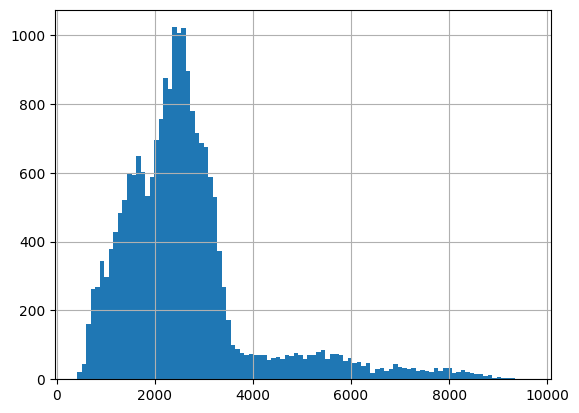

In [53]:
df["sharpness"].hist(bins=100)

In [56]:
df["sharpness"].describe()

count    21482.000000
mean      2633.903671
std       1403.139282
min        421.272879
25%       1757.787723
50%       2423.223030
75%       3000.207307
max       9615.704891
Name: sharpness, dtype: float64

In [61]:
from PIL import Image

<Axes: >

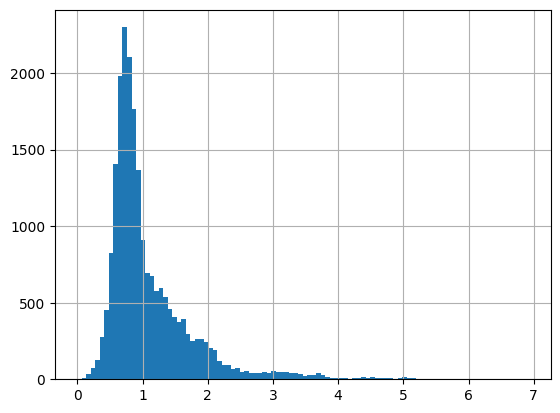

In [55]:
df["dist"].hist(bins=100)

In [41]:
df["dist"].describe()

count    21261.000000
mean         0.782123
std          0.738617
min          0.000000
25%          0.585137
50%          0.674461
75%          0.794229
max         15.590028
Name: dist, dtype: float64

In [21]:
df["dist"].std() * 3

np.float64(1.1117524184601217)

In [12]:
df.to_pickle("matthias_horizontal_4_rings_frames_1.pkl")

In [ ]:
sharp_thresh = df["sharpness"].quantile(1 - args.sharpness_quantile)
import code; code.interact(local=locals())
print("filtered out based on sharpness", len(df["sharpness"] > sharp_thresh))

df = df[df["sharpness"] > sharp_thresh]  # Filter out blurrier images.
df = sample_local_distance(df, args.motion_segment, sharpness_column="sharpness")

print(f"Final number of frames {len(df)}")


In [ ]:

if not args.output:
    output = frames_root.parent / (frames_root.name + "_sampled") / (scene.name + f"_sampled_{len(df)}/")
else:
    output = Path(args.output)
output.mkdir(exist_ok=True, parents=True)
for _, row in df.iterrows():
    shutil.copy(row["name"], output / Path(row["name"]).name) 

In [ ]:
def main():
    parser = argparse.ArgumentParser(prog='Frame Sampler')
    parser.add_argument('--data_root', required=True, help='Source directory containing frames to be subsampled, frames have to be named in alphabetical order')
    parser.add_argument('--output', required=False, help='Destination directory to copy sampled frames over. Will be created if it does not exist')
    parser.add_argument('--motion_segment', type=int, help='Amount of motion per sampled frame. also correlates with the final number of frames', default=60)
    parser.add_argument('--sharpness_quantile', type=float, help='What percentile of sharp frames to keep', default=0.8)
    parser.add_argument('--accept_all', action='store_true', help='Copy frames over without confirmation prompt')
    
    args = parser.parse_args()
    
    print("The frames in the framedir are expected to be named in alphabetical order")

    frames_root = Path(args.data_root)
    subdirs = [subdir for subdir in frames_root.iterdir() if subdir.is_dir()]
    if any(subdirs):
        scenes = subdirs
    else:
        scenes = [frames_root]
    
    for scene in scenes:
        print(scene)
        

if __name__ == "__main__":
    main()